<a href="https://colab.research.google.com/github/JuanPabloRodriguezC/ESC50-Image-Classification/blob/main/ProyectoIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto #1 de IA

In [1]:
# Bibliotecas
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader, Dataset


from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

In [21]:
import wandb

# Login (you'll need to create a free account at wandb.ai)
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/juanpablorodriguez/.netrc.
wandb: Currently logged in as: jprodriguezcano99 (jprodriguezcano99-tecnol-gico-de-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Codigo opcional para tener acceso a archivos de Drive
from google.colab import drive
drive.mount('/content/drive')

In [2]:
# Hiperparametros
batch_size = 32
image_size = (224,224)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [3]:
# Configurar direcciones de dataset
csv_path = "./nuevo.csv"
dir_crudo = "./dataset"
dir_aumentado = "./augmented_dataset"

## Preprocesamiento

### Funciones

In [5]:
def gaussian_noise(img_array: np.ndarray, std: float = 10.0) -> np.ndarray:
    """
    Add random Gaussian noise to every pixel.
    Simulates microphone noise or background hiss.
 
    Args:
        img_array: H×W×C uint8 array
        std:       noise standard deviation (0–255 scale); default 10
    """
    noise = np.random.normal(0, std, img_array.shape)
    noisy = img_array.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)
 
 
def time_shift(img_array: np.ndarray, max_shift_frac: float = 0.2) -> np.ndarray:
    """
    Shift the spectrogram left or right along the time axis (horizontal).
    Simulates the recording starting earlier or later.
    Wrapped region is filled with the column-mean (silence approximation).
 
    Args:
        img_array:       H×W×C uint8 array
        max_shift_frac:  maximum shift as a fraction of width; default 0.2
    """
    width = img_array.shape[1]
    max_shift = int(width * max_shift_frac)
    shift = random.randint(-max_shift, max_shift)
 
    result = np.zeros_like(img_array)
    col_mean = img_array.mean(axis=(0, 1)).astype(np.uint8)
 
    if shift > 0:
        result[:, shift:, :] = img_array[:, :width - shift, :]
        result[:, :shift, :] = col_mean
    elif shift < 0:
        result[:, :width + shift, :] = img_array[:, -shift:, :]
        result[:, width + shift:, :] = col_mean
    else:
        result = img_array.copy()
 
    return result
 
 
def time_masking(img_array: np.ndarray,
                 num_masks: int = 1,
                 max_mask_frac: float = 0.15) -> np.ndarray:
    """
    Zero out one or more random vertical strips along the time axis (SpecAugment T).
    Forces the model not to rely on any single time segment.
 
    Args:
        img_array:     H×W×C uint8 array
        num_masks:     number of independent masks to apply; default 1
        max_mask_frac: maximum width of each mask as fraction of total width; default 0.15
    """
    result = img_array.copy()
    width = img_array.shape[1]
    max_mask_width = max(1, int(width * max_mask_frac))
 
    for _ in range(num_masks):
        mask_width = random.randint(1, max_mask_width)
        start = random.randint(0, width - mask_width)
        result[:, start:start + mask_width, :] = 0
 
    return result
 
 
def frequency_masking(img_array: np.ndarray,
                      num_masks: int = 1,
                      max_mask_frac: float = 0.15) -> np.ndarray:
    """
    Zero out one or more random horizontal strips along the frequency axis (SpecAugment F).
    Forces the model not to rely on any single frequency band.
 
    Args:
        img_array:     H×W×C uint8 array
        num_masks:     number of independent masks to apply; default 1
        max_mask_frac: maximum height of each mask as fraction of total height; default 0.15
    """
    result = img_array.copy()
    height = img_array.shape[0]
    max_mask_height = max(1, int(height * max_mask_frac))
 
    for _ in range(num_masks):
        mask_height = random.randint(1, max_mask_height)
        start = random.randint(0, height - mask_height)
        result[start:start + mask_height, :, :] = 0
 
    return result
 
 
def frequency_shift(img_array: np.ndarray, max_shift_frac: float = 0.1) -> np.ndarray:
    """
    Shift the spectrogram up or down along the frequency axis (vertical).
    Simulates slight pitch transposition of the source sound.
    Vacated rows are filled with the row-mean (silence approximation).
 
    Args:
        img_array:       H×W×C uint8 array
        max_shift_frac:  maximum shift as a fraction of height; default 0.1
    """
    height = img_array.shape[0]
    max_shift = int(height * max_shift_frac)
    shift = random.randint(-max_shift, max_shift)
 
    result = np.zeros_like(img_array)
    row_mean = img_array.mean(axis=(0, 1)).astype(np.uint8)
 
    if shift > 0:
        result[shift:, :, :] = img_array[:height - shift, :, :]
        result[:shift, :, :] = row_mean
    elif shift < 0:
        result[:height + shift, :, :] = img_array[-shift:, :, :]
        result[height + shift:, :, :] = row_mean
    else:
        result = img_array.copy()
 
    return result
 
 
def amplitude_scaling(img_array: np.ndarray,
                      scale_range: tuple = (0.7, 1.3)) -> np.ndarray:
    """
    Multiply pixel intensities by a random scalar factor.
    Simulates recordings at different loudness levels.
 
    Args:
        img_array:   H×W×C uint8 array
        scale_range: (min_scale, max_scale) multiplicative range; default (0.7, 1.3)
    """
    scale = random.uniform(*scale_range)
    scaled = img_array.astype(np.float32) * scale
    return np.clip(scaled, 0, 255).astype(np.uint8)
 
 
def mixup(img_array: np.ndarray,
          other_array: np.ndarray,
          alpha: float = 0.3) -> np.ndarray:
    """
    Blend two spectrograms with a Beta-distributed weight (Mixup).
    Encourages linear interpolation behaviour in the model's feature space.
 
    Args:
        img_array:   first spectrogram, H×W×C uint8
        other_array: second spectrogram, must be same shape
        alpha:       Beta distribution concentration parameter; default 0.3
    """
    lam = np.random.beta(alpha, alpha)
    blended = lam * img_array.astype(np.float32) + (1 - lam) * other_array.astype(np.float32)
    return np.clip(blended, 0, 255).astype(np.uint8)

def load_image(path: Path) -> np.ndarray:
    img = Image.open(path).convert("RGB")
    return np.array(img)
 
 
def save_image(array: np.ndarray, path: Path) -> None:
    Image.fromarray(array).save(path)

In [6]:
def augment_dataset(input_dir: str,
                    output_dir: str,
                    augmentations: list[str],
                    copies: int,
                    use_mixup: bool,
                    seed: int) -> None:
 
    random.seed(seed)
    np.random.seed(seed)
 
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
 
    # Gather all PNG files (including subdirectories)
    all_images = sorted(input_path.rglob("*.png"))
    if not all_images:
        print(f"[!] No PNG files found in '{input_dir}'. Exiting.")
        return
 
    print(f"[+] Found {len(all_images)} PNG files.")
    print(f"[+] Augmentations : {augmentations}")
    print(f"[+] Copies per image: {copies}")
    print(f"[+] Mixup enabled : {use_mixup}")
    print(f"[+] Output dir    : {output_path}\n")
 
    selected_fns = [fn for fn in augmentations]
 
    if not selected_fns and not use_mixup:
        print("[!] No valid augmentations selected. Use --augmentations and/or --mixup.")
        return
 
    # Copy originals first
    print("Copying originals...")
    for img_path in tqdm(all_images):
        rel = img_path.relative_to(input_path)
        dest = output_path / rel
        dest.parent.mkdir(parents=True, exist_ok=True)
        save_image(load_image(img_path), dest)
 
    # Apply augmentations
    print("\nGenerating augmented copies...")
    for img_path in tqdm(all_images):
        base_array = load_image(img_path)
        rel        = img_path.relative_to(input_path)
        stem       = img_path.stem
        dest_dir   = (output_path / rel).parent
 
        for copy_idx in range(1, copies + 1):
            aug_array = base_array.copy()
 
            # Apply each selected augmentation sequentially
            for fn in selected_fns:
                aug_array = fn(aug_array)
 
            # Optional mixup with a random other image
            if use_mixup:
                other_path = random.choice(all_images)
                other_array = load_image(other_path)
                # Resize other to match if needed
                if other_array.shape != aug_array.shape:
                    other_img = Image.fromarray(other_array).resize(
                        (aug_array.shape[1], aug_array.shape[0]), Image.BILINEAR
                    )
                    other_array = np.array(other_img)
                aug_array = mixup(aug_array, other_array)
 
            out_name = f"{stem}_aug{copy_idx:03d}.png"
            save_image(aug_array, dest_dir / out_name)
 
    total_orig = len(all_images)
    total_aug  = total_orig * copies
    print(f"\n{total_orig} originals + {total_aug} augmented = {total_orig + total_aug} total images.")
    print(f"   Saved to: {output_path}")

In [7]:
def set_dataset_paths(df, base_dir, validate=True):
  df['path'] = df['filename'].apply(lambda x: os.path.join(base_dir, x))
  df = df[df['path'].apply(os.path.exists)]

  # valida si los archivos no están rotos
  if validate:
    valid_paths = []
    modes_detected = set()
    for path in tqdm(df['path'], desc=f"Validando imágenes en {base_dir}"):
        try:
            with Image.open(path) as img:
                img.verify()
            with Image.open(path) as img:
                modes_detected.add(img.mode)
                if img.mode == "RGBA":
                    valid_paths.append(path)
        except Exception:
            pass

    df = df[df['path'].isin(valid_paths)]
    print(f"Imágenes válidas: {len(valid_paths)} | Modos detectados: {modes_detected}")

  return df

In [8]:
def preprocesa_imagenes(df):
    # Guardar copia original para graficar antes/después
    df_original = df.copy()

    # --- Balanceo del dataset ---
    min_class = df['category'].value_counts().min()
    df_balanced = (
    df.groupby('category')
      .sample(n=min_class, random_state=42)
      .reset_index(drop=True)
    )

    print("\nDataset balanceado:")
    print(df_balanced['category'].value_counts())

    # --- Cálculo de brillo promedio para df_balanced ---
    brightness_list = []
    for path in tqdm(df_balanced['path'], desc="Analizando brillo"):
        with Image.open(path) as img:
            arr = np.array(img)
            # Asegurarse de tener al menos 3 canales
            if arr.ndim == 2:
                arr = np.stack([arr]*3, axis=-1)
            brightness = arr[..., :3].mean()
            brightness_list.append(brightness)
    df_balanced['brightness'] = brightness_list

    # --- Cálculo de brillo del original (para comparación) ---
    original_brightness = []
    for path in tqdm(df_original['path'], desc="Analizando brillo (original)"):
        with Image.open(path) as img:
            arr = np.array(img)
            if arr.ndim == 2:
                arr = np.stack([arr]*3, axis=-1)
            original_brightness.append(arr[..., :3].mean())

    # --- Graficar comparativo ---
    plt.figure(figsize=(12,5))
    plt.hist(original_brightness, bins=40, alpha=0.6, label='Original')
    plt.hist(df_balanced['brightness'], bins=40, alpha=0.6, label='Balanceado')
    plt.legend()
    plt.title('Distribución de brillo: original vs balanceado')
    plt.show()

    # --- Detección de outliers sobre df_balanced ---
    q1, q3 = np.percentile(df_balanced['brightness'], [25, 75])
    iqr = q3 - q1
    upper_limit = q3 + 1.5 * iqr
    lower_limit = q1 - 1.5 * iqr

    num_outliers = ((df_balanced['brightness'] > upper_limit) |
                    (df_balanced['brightness'] < lower_limit)).sum()

    if num_outliers > 0:
        print(f"→ {num_outliers} outliers detectados; aplicando Winsorization...")
        df_balanced['brightness'] = winsorize(df_balanced['brightness'], limits=[0.025, 0.025])
    else:
        print("→ No se detectaron outliers; no se aplica Winsorization.")

    return df_balanced


Codificación de etiquetas

In [9]:
def codifica_etiquetas(df):
  label_encoder = LabelEncoder()
  df['label'] = label_encoder.fit_transform(df['category'])
  num_clases = len(label_encoder.classes_)
  print(f"Clases codificadas: {num_clases}")
  return df, num_clases

División Estratégica (clase + brillo)

In [10]:
def division_dataset(df, nbins=5):
    """
    División estratégica de dataset en train, val y test.
    Balancea por clase y brillo, y evita errores de StratifiedShuffleSplit.
    """
    df_balanced = df.copy()

    # --- BALANCEO INTELIGENTE ---
    class_counts = df_balanced['category'].value_counts()
    min_class = class_counts.min()
    max_class = class_counts.max()
    class_ratio = max_class / min_class

    if class_ratio > 10:
        target_size = min(int(min_class * 2), int(max_class * 0.6))
    elif class_ratio > 5:
        target_size = min(int(min_class * 1.8), int(max_class * 0.7))
    elif class_ratio > 2:
        target_size = min(int(min_class * 1.5), int(max_class * 0.8))
    else:
        target_size = min_class

    def sample_strategy(group):
        return group.sample(min(len(group), target_size), random_state=42)

    df_balanced = df_balanced.groupby('category').sample(n=min(len(df_balanced), target_size), random_state=42).reset_index(drop=True)

    # --- CÁLCULO DE BRILLO ---
    brightness_list = []
    for path in tqdm(df_balanced['path'], desc="Analizando brillo"):
        with Image.open(path) as img:
            arr = np.array(img)
            if arr.ndim == 2:
                arr = np.stack([arr]*3, axis=-1)
            brightness_list.append(arr[..., :3].mean())
    df_balanced['brightness'] = brightness_list

    # --- Ajustar nbins según mínimo de muestras por clase ---
    nbins_adjusted = min(nbins, min(df_balanced['category'].value_counts()) // 2)
    if nbins_adjusted < 2:
        nbins_adjusted = 2  # al menos 2 bins

    df_balanced['brightness_bin'] = pd.cut(df_balanced['brightness'],
                                           bins=nbins_adjusted,
                                           labels=False,
                                           include_lowest=True)
    df_balanced['stratify_col'] = df_balanced['category'].astype(str) + '_' + df_balanced['brightness_bin'].astype(str)

    # --- Eliminar grupos con solo 1 muestra globalmente ---
    stratify_counts = df_balanced['stratify_col'].value_counts()
    single_sample_groups = stratify_counts[stratify_counts == 1].index
    if len(single_sample_groups) > 0:
        print(f"→ Eliminando {len(single_sample_groups)} grupos con solo 1 muestra")
        df_balanced = df_balanced[~df_balanced['stratify_col'].isin(single_sample_groups)].reset_index(drop=True)

    # --- Primera división: Train vs Val+Test (70/30) ---
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, val_test_idx = next(sss1.split(df_balanced, df_balanced['stratify_col']))
    train_df = df_balanced.iloc[train_idx].reset_index(drop=True)
    val_test_df = df_balanced.iloc[val_test_idx].reset_index(drop=True)

    # --- Eliminar grupos con solo 1 muestra en Val+Test ---
    stratify_counts = val_test_df['stratify_col'].value_counts()
    single_sample_groups = stratify_counts[stratify_counts == 1].index
    if len(single_sample_groups) > 0:
        print(f"→ Eliminando {len(single_sample_groups)} grupos con solo 1 muestra en val+test")
        val_test_df = val_test_df[~val_test_df['stratify_col'].isin(single_sample_groups)].reset_index(drop=True)

    # --- Segunda división: Validation vs Test (50/50 de val+test) ---
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    val_idx, test_idx = next(sss2.split(val_test_df, val_test_df['stratify_col']))
    val_df = val_test_df.iloc[val_idx].reset_index(drop=True)
    test_df = val_test_df.iloc[test_idx].reset_index(drop=True)

    print(f"\n=== DIVISIÓN ESTRATÉGICA ===")
    print(f" Train set: {len(train_df)} imágenes")
    print(f" Validation set: {len(val_df)} imágenes")
    print(f" Test set: {len(test_df)} imágenes")

    return train_df, val_df, test_df


Transformaciones RGBA (Aumentos de Datos)

Dataset Personalizado RGBA

In [11]:
class CustomImageDatasetRGBA(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        label = int(self.dataframe.iloc[idx]['label'])
        image = Image.open(img_path)
        if image.mode != "RGBA":
            image = image.convert("RGBA")
        if self.transform:
            image = self.transform(image)
        return image, label

### Data Augmentation

In [13]:
copies=5
augment_dataset(dir_crudo, dir_aumentado, [gaussian_noise, time_shift, time_masking, frequency_masking, frequency_shift, amplitude_scaling], copies=5, use_mixup=False, seed=42)

[+] Found 2001 PNG files.
[+] Augmentations : [<function gaussian_noise at 0x31534d580>, <function time_shift at 0x31534d620>, <function time_masking at 0x31534d6c0>, <function frequency_masking at 0x31534d760>, <function frequency_shift at 0x31534d800>, <function amplitude_scaling at 0x31534d8a0>]
[+] Copies per image: 5
[+] Mixup enabled : False
[+] Output dir    : augmented_dataset

Copying originals...


100%|██████████████████████████████████████| 2001/2001 [00:03<00:00, 613.04it/s]



Generating augmented copies...


100%|███████████████████████████████████████| 2001/2001 [00:29<00:00, 68.43it/s]


2001 originals + 10005 augmented = 12006 total images.
   Saved to: augmented_dataset


### Carga Datasets

In [28]:
#Cargar CSV crudo y definir rutas
df = pd.read_csv(csv_path)
df.dropna(subset=['filename', 'category'], inplace=True)
print(f"Total de muestras: {len(df)}")
print(df.head())

Total de muestras: 2000
            filename        category
0   1-100032-A-0.png             dog
1  1-100038-A-14.png  chirping_birds
2  1-100210-A-36.png  vacuum_cleaner
3  1-100210-B-36.png  vacuum_cleaner
4  1-101296-A-19.png    thunderstorm


In [20]:
aug_rows = []
 
for _, row in df.iterrows():
    original_filename = row['filename']
    stem = Path(original_filename).stem
    ext  = Path(original_filename).suffix

    for i in range(1, copies + 1):
        aug_row = row.copy()
        aug_row['filename'] = f"{stem}_aug{i:03d}{ext}"
        aug_rows.append(aug_row)

df_aug = pd.DataFrame(aug_rows)
df_expanded = pd.concat([df, df_aug], ignore_index=True)

df_expanded = df_expanded.sort_values('filename').reset_index(drop=True)

Validando imágenes en ./dataset: 100%|███| 2000/2000 [00:00<00:00, 13575.14it/s]


Imágenes válidas: 2000 | Modos detectados: {'RGBA'}

Dataset balanceado:
category
airplane            40
breathing           40
brushing_teeth      40
can_opening         40
car_horn            40
cat                 40
chainsaw            40
chirping_birds      40
church_bells        40
clapping            40
clock_alarm         40
clock_tick          40
coughing            40
cow                 40
crackling_fire      40
crickets            40
crow                40
crying_baby         40
dog                 40
door_wood_creaks    40
door_wood_knock     40
drinking_sipping    40
engine              40
fireworks           40
footsteps           40
frog                40
glass_breaking      40
hand_saw            40
helicopter          40
hen                 40
insects             40
keyboard_typing     40
laughing            40
mouse_click         40
pig                 40
pouring_water       40
rain                40
rooster             40
sea_waves           40
sheep               4

Analizando brillo (original): 100%|███████| 2000/2000 [00:01<00:00, 1855.42it/s]


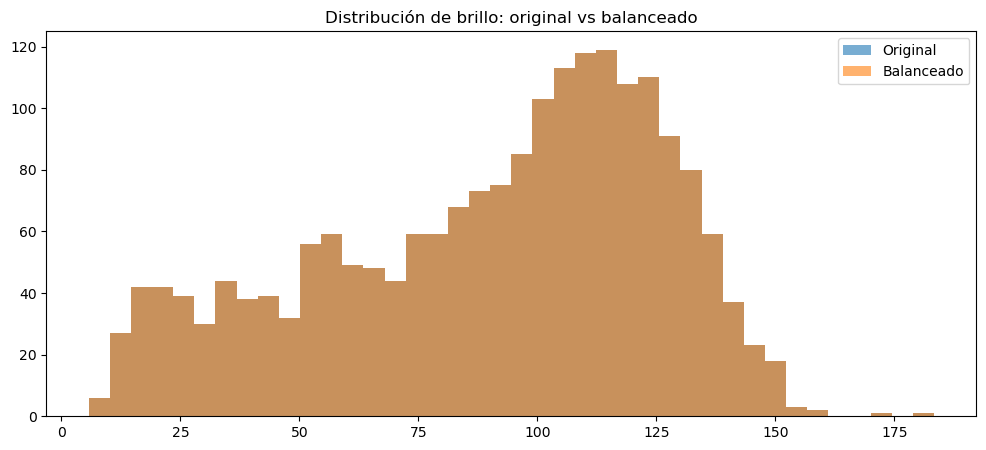

→ No se detectaron outliers; no se aplica Winsorization.
Clases codificadas: 50


Analizando brillo: 100%|██████████████████| 2000/2000 [00:01<00:00, 1854.37it/s]

→ Eliminando 15 grupos con solo 1 muestra
→ Eliminando 36 grupos con solo 1 muestra en val+test

=== DIVISIÓN ESTRATÉGICA ===
 Train set: 1389 imágenes
 Validation set: 280 imágenes
 Test set: 280 imágenes


In [46]:
#crudo
df_crudo = set_dataset_paths(df, dir_crudo, validate=True)
df_crudo = preprocesa_imagenes(df_crudo)
df_crudo, num_clases = codifica_etiquetas(df_crudo)

train_raw, val_raw, test_raw = division_dataset(df_crudo)


Dataset balanceado:
category
airplane            240
breathing           240
brushing_teeth      240
can_opening         240
car_horn            240
cat                 240
chainsaw            240
chirping_birds      240
church_bells        240
clapping            240
clock_alarm         240
clock_tick          240
coughing            240
cow                 240
crackling_fire      240
crickets            240
crow                240
crying_baby         240
dog                 240
door_wood_creaks    240
door_wood_knock     240
drinking_sipping    240
engine              240
fireworks           240
footsteps           240
frog                240
glass_breaking      240
hand_saw            240
helicopter          240
hen                 240
insects             240
keyboard_typing     240
laughing            240
mouse_click         240
pig                 240
pouring_water       240
rain                240
rooster             240
sea_waves           240
sheep               240
siren     

Analizando brillo (original): 100%|█████| 12000/12000 [00:05<00:00, 2275.54it/s]


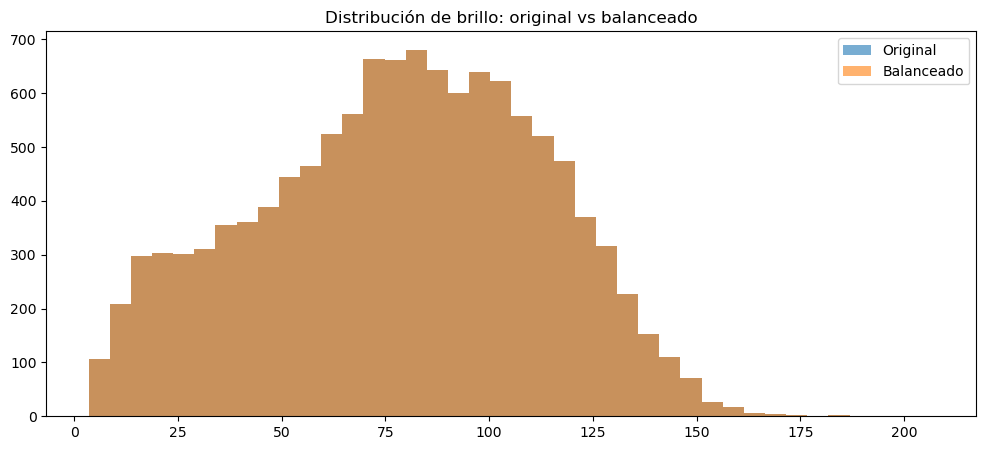

→ 4 outliers detectados; aplicando Winsorization...
Clases codificadas: 50


Analizando brillo: 100%|████████████████| 14000/14000 [00:06<00:00, 2201.65it/s]

→ Eliminando 8 grupos con solo 1 muestra
→ Eliminando 13 grupos con solo 1 muestra en val+test

=== DIVISIÓN ESTRATÉGICA ===
 Train set: 9794 imágenes
 Validation set: 2092 imágenes
 Test set: 2093 imágenes


In [49]:
#aumentado
df_aumentado = set_dataset_paths(df_expanded, dir_aumentado, validate=False)
df_aumentado = preprocesa_imagenes(df_aumentado)
df_aumentado, num_clases = codifica_etiquetas(df_aumentado)
df_aumentado = pd.concat([df_aumentado, df_crudo], ignore_index=True)
train_aug, val_aug, test_aug = division_dataset(df_aumentado)

In [50]:
df_crudo.to_csv('df_crudo.csv', index=False)
df_aumentado.to_csv('df_aumentado.csv', index=False)

In [12]:
#carga datos previamente guardados
df_crudo = pd.read_csv('df_crudo.csv')
df_aumentado = pd.read_csv('df_aumentado.csv')

train_raw, val_raw, test_raw = division_dataset(df_crudo)
train_aug, val_aug, test_aug = division_dataset(df_aumentado)

Analizando brillo: 100%|██████████████████| 2000/2000 [00:01<00:00, 1833.02it/s]


→ Eliminando 15 grupos con solo 1 muestra
→ Eliminando 36 grupos con solo 1 muestra en val+test

=== DIVISIÓN ESTRATÉGICA ===
 Train set: 1389 imágenes
 Validation set: 280 imágenes
 Test set: 280 imágenes


Analizando brillo: 100%|████████████████| 14000/14000 [00:06<00:00, 2204.94it/s]

→ Eliminando 8 grupos con solo 1 muestra
→ Eliminando 13 grupos con solo 1 muestra en val+test

=== DIVISIÓN ESTRATÉGICA ===
 Train set: 9794 imágenes
 Validation set: 2092 imágenes
 Test set: 2093 imágenes


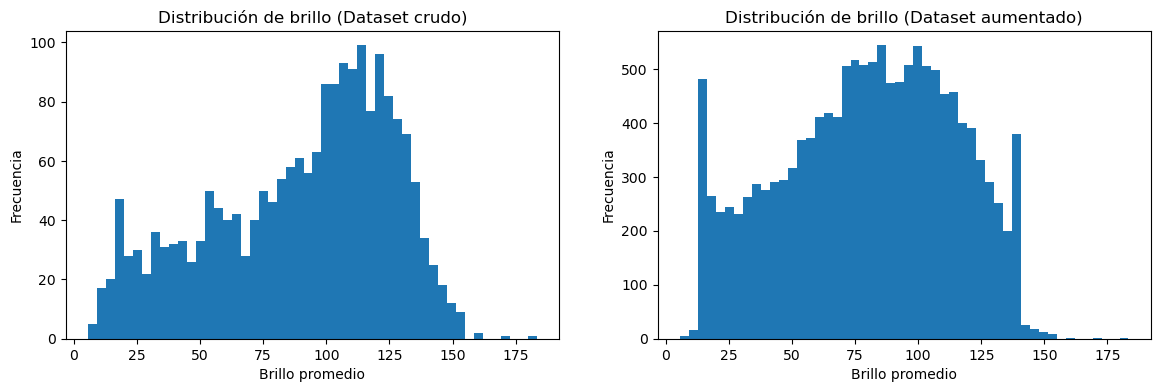

In [13]:
# Histograma brillo
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.hist(df_crudo['brightness'], bins=50)
plt.title("Distribución de brillo (Dataset crudo)")
plt.xlabel("Brillo promedio")
plt.ylabel("Frecuencia")
plt.subplot(1, 2, 2)
plt.hist(df_aumentado['brightness'], bins=50)
plt.title("Distribución de brillo (Dataset aumentado)")
plt.xlabel("Brillo promedio")
plt.ylabel("Frecuencia")
plt.show()

DataLoaders

In [13]:
transform_rgba = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*4, std=[0.5]*4)
])

In [53]:
train_dataset_raw = CustomImageDatasetRGBA(train_raw, transform=transform_rgba)
val_dataset_raw   = CustomImageDatasetRGBA(val_raw, transform=transform_rgba)
test_dataset_raw  = CustomImageDatasetRGBA(test_raw, transform=transform_rgba)

train_loader_raw = DataLoader(train_dataset_raw, batch_size=batch_size, shuffle=True)
val_loader_raw   = DataLoader(val_dataset_raw, batch_size=batch_size)
test_loader_raw  = DataLoader(test_dataset_raw, batch_size=batch_size)

# --- VERIFICACIÓN ---
sample_images, sample_labels = next(iter(train_loader_raw))
print(f"Shape batch imágenes: {sample_images.shape}")  # [batch, 4, 224, 224]
print(f"Shape batch labels: {sample_labels.shape}")

Shape batch imágenes: torch.Size([32, 4, 224, 224])
Shape batch labels: torch.Size([32])


In [14]:
train_dataset_aug = CustomImageDatasetRGBA(train_aug, transform=transform_rgba)
val_dataset_aug   = CustomImageDatasetRGBA(val_aug, transform=transform_rgba)
test_dataset_aug  = CustomImageDatasetRGBA(test_aug, transform=transform_rgba)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
val_loader_aug   = DataLoader(val_dataset_aug, batch_size=batch_size)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=batch_size)

# --- VERIFICACIÓN ---
sample_images, sample_labels = next(iter(train_loader_aug))
print(f"Shape batch imágenes: {sample_images.shape}")  # [batch, 4, 224, 224]
print(f"Shape batch labels: {sample_labels.shape}")

Shape batch imágenes: torch.Size([32, 4, 224, 224])
Shape batch labels: torch.Size([32])


# Modelos

### Funciones

In [15]:
# --- Entrenamiento con early stopping ---
def train(model, train_loader, val_loader, costFunction, optimizer, num_epochs, patience, device):

    best_val_acc = 0
    early_stop_counter = 0
    model = model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = costFunction(outputs, labels)
            loss.backward()

            # Gradient Clipping para evitar explosión de gradientes
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        # Validación
        model.eval()
        correct_val = 0
        total_val = 0
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = costFunction(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * correct_val / total_val

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "learning_rate": optimizer.param_groups[0]['lr'],
            'overfitting/acc_gap': train_acc - val_acc,
            'overfitting/loss_ratio': val_loss / train_loss if train_loss > 0 else 0
        })

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
        print("-" * 50)

        # Early stopping mejorado
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            early_stop_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
            wandb.save('best_model.pth')
            print(f" Nuevo mejor modelo: {val_acc:.2f}%")
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f" Early stopping activado después de {epoch+1} épocas")
                break

In [16]:
def train_sweep():
  run = wandb.init()
  config = wandb.config

  if config.model_name == 'lenet5':
      model = LeNet5(
          num_classes=config.num_classes
      ).to(config.device)
  elif config.model_name == 'lenet5Dropout':
      model = LeNet5Dropout(
          num_classes=config.num_classes,
          dropout=config.dropout
      ).to(config.device)
  elif config.model_name == 'customModel':
    model = CustomCNN(
        num_classes=config.num_classes,
        dropout=config.dropout
    )
  else:
      raise ValueError(f"Unknown model: {config.model_name}")

  if config.dataset_type == 'raw':
      train_loader = train_loader_raw
      val_loader = val_loader_raw
  elif config.dataset_type == 'augmented':
      train_loader = train_loader_aug
      val_loader = val_loader_aug
  else:
      raise ValueError(f"Unknown dataset type: {config.dataset_type}")


  if config.optimizer == 'adam':
      optimizer = torch.optim.Adam(
          model.parameters(),
          lr=config.learning_rate,
          weight_decay=config.weight_decay
      )
  elif config.optimizer == 'sgd':
      optimizer = torch.optim.SGD(
          model.parameters(),
          lr=config.learning_rate,
          momentum=0.9,
          weight_decay=config.weight_decay
      )
  else:
      raise ValueError(f"Unknown optimizer: {config.optimizer}")

  cost = nn.CrossEntropyLoss()

  device = torch.device(config.device)

  train(
      model=model,
      train_loader=train_loader,
      val_loader=val_loader,
      costFunction=cost,
      optimizer=optimizer,
      num_epochs=config.epochs,
      patience=config.patience,
      device=device
  )

  wandb.finish()

In [17]:
def test(model, test_loader):
  model.load_state_dict(torch.load("best_model.pth"))
  model.eval()

  all_labels = []
  all_preds = []
  all_probs = []
  test_loss = 0.0
  test_correct = 0
  test_total = 0

  with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)  # Shape: [batch, num_classes]
          probs = F.softmax(outputs, dim=1)
          _, predicted = torch.max(outputs, 1)

          all_labels.extend(labels.cpu().numpy())
          all_preds.extend(predicted.cpu().numpy())
          all_probs.extend(probs.cpu().numpy())

  # Convertir a arrays
  all_labels = np.array(all_labels)
  all_preds = np.array(all_preds)
  all_probs = np.array(all_probs)

  wandb.log({
        "test_accuracy": accuracy,
        "test_confusion_matrix": wandb.plot.confusion_matrix(
            probs=None,
            y_true=all_labels,
            preds=all_preds,
            class_names=[str(i) for i in range(num_clases)]
        )
    })

  # Métricas test
  accuracy = 100 * (all_preds == all_labels).sum() / len(all_labels)
  precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
  recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
  f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
  auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

  print(f"Test Accuracy: {accuracy:.2f}%")
  print(f"Test Precision: {precision:.4f}")
  print(f"Test Recall: {recall:.4f}")
  print(f"Test F1 Score: {f1:.4f}")
  print(f"Test AUC: {auc:.4f}")

## LeNet

### Arquitectura

Cálculo el tamaño de salida

Cada vez que aplicás una convolución o un pooling, el tamaño cambia según esta fórmula:

Salida=[(𝑊−𝐾+2𝑃)/𝑆]+1

Donde:

W: tamaño de entrada (ancho o alto)

K: tamaño del kernel

P: padding

S: stride

Red LeNet5 modificada
Capas convolucionales:

 Entrada: 224 × 224 (con 4 canales)

Después de la primera convolución (Conv2d(4,6,5x5, s=1, p=0))

Usando la fórmula:

(224−5+2×0/1)+1=220


Salida: 220 × 220
forma : 6 × 220 × 220

Después del primer AvgPool (2×2, stride=2)

(220−2/2)+1=110

Salida: 110 × 110 →
forma : 6 × 110 × 110

Segunda convolución (Conv2d(6,16,5x5, s=1, p=0))

(110−5+0/1)+1=106


Salida: 106 × 106
forma: 16 × 106 × 106

Segundo AvgPool (2×2, stride=2)

(106−2/2)+1=53

Salida: 53 × 53
 forma final: 16 × 53 × 53

Tercera convolución (Conv2d(16,120,5x5, s=1, p=0))

(53−5+0/1)+1=49


Salida: 49 × 49
forma: 120 × 49 × 49

Cálculo del tamaño total para la capa fully connected (flatten)

Número de entradas=120×49×49

49×49=2401

120×2401=288,120

In [19]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()

        # Capa 1: Conv -> Tanh -> AvgPool
        self.layer1 = nn.Sequential(
            nn.Conv2d(4, 6, kernel_size=5, stride=1, padding=0),  # (4,224,224) -> (6,220,220)
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2)                 # -> (6,110,110)
        )

        # Capa 2: Conv -> Tanh -> AvgPool
        self.layer2 = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0), # -> (16,106,106)
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2)                 # -> (16,53,53)
        )

        # Capa 3: Conv -> Tanh
        self.conv3 = nn.Sequential(
            nn.Conv2d(16, 120, kernel_size=5, stride=1, padding=0),  # -> (120,49,49)
            nn.Tanh()
        )

        # Capa fully-connected (calculado manualmente)
        self.fc1 = nn.Linear(288120, 84)  # 120*49*49 = 288120
        self.tanh1 = nn.Tanh()

        # Capa de salida
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.conv3(out)
        out = out.view(out.size(0), -1)  # flatten
        out = self.fc1(out)
        out = self.tanh1(out)
        out = self.fc2(out)
        return out

### Entrenamiento (Datos Crudos)

In [ ]:
sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'best_val_acc',
        'goal': 'maximize'
    },
    'parameters': {
        'model_name': {
            'values': ['lenet5']
        },
        'dataset_type': {
            'values': ['raw', 'augmented']
        },
        'learning_rate': {
            'values': [0.0001, 0.0005, 0.001]
        },
        'weight_decay': {
            'values': [1e-4, 1e-3, 1e-2]
        },
        'dropout': {
            'values': [0.3, 0.5, 0.7]
        },
        'batch_size': {
            'values': [32, 64]
        },
        'optimizer': {
            'value': 'adam'
        },
        'epochs': {
            'value': 40
        },
        'patience': {
            'value': 7
        },
        'num_classes': {
            'value': 50
        },
        'device': {
            'value': 'cuda' if torch.cuda.is_available() else 'cpu'
        }
    }
}

In [ ]:
sweep_id = wandb.sweep(sweep_config, project='proyecto-ia-sweep-lenet5')
wandb.agent(sweep_id, function=train_sweep, count=10)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Create sweep with ID: boyfd71z
Sweep URL: https://wandb.ai/luisperezdb9-tec/proyecto-ia-sweep-lenet5/sweeps/boyfd71z


wandb: Agent Starting Run: 20aue9ju with config:
wandb: 	batch_size: 64
wandb: 	dataset_type: raw
wandb: 	device: cuda
wandb: 	dropout: 0.7
wandb: 	epochs: 40
wandb: 	learning_rate: 0.001
wandb: 	model_name: lenet5
wandb: 	num_classes: 50
wandb: 	optimizer: adam
wandb: 	patience: 7
wandb: 	weight_decay: 0.0001


Epoch 1:   0%|          | 0/44 [00:00<?, ?it/s]Exception in thread ChkStopThr:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/wandb_run.py", line 308, in check_stop_status
    self._loop_check_status(
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/wandb_run.py", line 238, in _loop_check_status
    local_handle = request()
Epoch 1:   2%|▏         | 1/44 [00:00<00:16,  2.56it/s]^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/interface/interface.py", line 992, in deliver_stop_status
    return self._deliver_stop_status(status)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/interface/interface_shared.py", line 442, in _deliver_stop_status
    return self._deliver(rec

Epoch 1/40
Train Loss: 3.8564 | Train Acc: 3.38%
Val Loss: 3.6306 | Val Acc: 6.43%
LR: 0.001000
--------------------------------------------------
 Nuevo mejor modelo: 6.43%


...

Epoch 15: 100%|██████████| 88/88 [00:23<00:00,  3.70it/s]


Epoch 15/40
Train Loss: 3.6874 | Train Acc: 5.88%
Val Loss: 3.6348 | Val Acc: 6.67%
LR: 0.001000
--------------------------------------------------
 Nuevo mejor modelo: 6.67%


Epoch 16: 100%|██████████| 88/88 [00:23<00:00,  3.68it/s]


Epoch 16/40
Train Loss: 3.6658 | Train Acc: 6.06%
Val Loss: 3.6621 | Val Acc: 3.76%
LR: 0.001000
--------------------------------------------------


Epoch 17:   7%|▋         | 6/88 [00:01<00:22,  3.68it/s]

In [ ]:
modelRaw = LeNet5(num_clases).to(device)

#Función de pérdida
cost = nn.CrossEntropyLoss()

#Configuración del optimizador con los parámetros del modelo y la tasa de aprendizaje
optimizer = torch.optim.Adam(modelRaw.parameters(), lr=0.0005, weight_decay=0.01)

#Esto se define para imprimir cuántos pasos quedan cuando se entrena.
total_step = len(train_loader_raw)


In [ ]:
train(modelRaw, train_loader_raw, val_loader_raw, cost, optimizer,num_epochs=50, patience=7,device=device)

Epoch 1: 100%|██████████| 44/44 [00:11<00:00,  3.85it/s]


Epoch 1/50
Train Loss: 3.9709 | Train Acc: 3.24%
Val Loss: 3.7671 | Val Acc: 3.93%
LR: 0.000500
--------------------------------------------------
 Nuevo mejor modelo: 3.93%


Epoch 2: 100%|██████████| 44/44 [00:12<00:00,  3.46it/s]


Epoch 2/50
Train Loss: 3.8286 | Train Acc: 4.32%
Val Loss: 3.7682 | Val Acc: 4.64%
LR: 0.000500
--------------------------------------------------
 Nuevo mejor modelo: 4.64%


Epoch 3: 100%|██████████| 44/44 [00:11<00:00,  3.68it/s]


...

Epoch 39/50
Train Loss: 2.7225 | Train Acc: 30.89%
Val Loss: 2.7939 | Val Acc: 24.29%
LR: 0.000500
--------------------------------------------------


Epoch 40: 100%|██████████| 44/44 [00:11<00:00,  3.85it/s]


Epoch 40/50
Train Loss: 2.7204 | Train Acc: 29.45%
Val Loss: 2.7748 | Val Acc: 26.43%
LR: 0.000500
--------------------------------------------------


Epoch 41: 100%|██████████| 44/44 [00:11<00:00,  3.84it/s]


Epoch 41/50
Train Loss: 2.7181 | Train Acc: 31.32%
Val Loss: 2.8248 | Val Acc: 23.93%
LR: 0.000500
--------------------------------------------------
 Early stopping activado después de 41 épocas


In [ ]:
test(modelRaw, test_loader_raw)


### Entrenamiento (Datos Aumentados)

In [ ]:
modelAug = LeNet5(num_clases).to(device)
#Configuración del optimizador con los parámetros del modelo y la tasa de aprendizaje
optimizerAug = torch.optim.Adam(modelAug.parameters(), lr=0.0005, weight_decay=0.01 )

#Esto se define para imprimir cuántos pasos quedan cuando se entrena.
total_stepAug = len(train_loader_aug)

In [ ]:
train(modelAug, train_loader_aug, val_loader_aug, cost, optimizerAug,num_epochs=50, patience=7,device=device)

Epoch 1: 100%|██████████| 88/88 [00:22<00:00,  3.87it/s]


NameError: name 'wandb' is not defined

In [ ]:
test(modelAug, test_loader_aug)

Debido a que el modelo LeNet5 no supera en los datos aumentados el 43.33 de precision en el Test, se agregara al Dropout a la arquitectura vanila de LeNet5

## LeNet5 con Dropout


In [18]:
class LeNet5Dropout(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super(LeNet5Dropout, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(4, 6, 5),
            nn.ReLU(),
            nn.AvgPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(6, 16, 5),
            nn.ReLU(),
            nn.AvgPool2d(2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(16, 120, 5),
            nn.ReLU()
        )
        self.fc1 = nn.Sequential(
            nn.Linear(288120, 84),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.conv3(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

### Datos crudos

In [ ]:
sweep_config_dropout = {
    'method': 'bayes',
    'metric': {
        'name': 'best_val_acc',
        'goal': 'maximize'
    },
    'parameters': {
        'model_name': {
            'values': ['lenet5Dropout']
        },
        'dataset_type': {
            'value': 'raw'
        },
        'learning_rate': {
            'values': [0.0001, 0.0005, 0.001]
        },
        'weight_decay': {
            'values': [1e-4, 1e-3, 1e-2]
        },
        'dropout': {
            'values': [0.3, 0.5, 0.7]
        },
        'batch_size': {
            'values': [32, 64]
        },
        'optimizer': {
            'values': ['adam', 'sgd']
        },
        'epochs': {
            'value': 40
        },
        'patience': {
            'value': 7
        },
        'num_classes': {
            'value': 50
        },
        'device': {
            'value': 'cuda' if torch.cuda.is_available() else 'cpu'
        }
    }
}

In [ ]:
sweep_id_dropout = wandb.sweep(sweep_config_dropout, project='proyecto-ia-sweep-lenet5dropout')
wandb.agent(sweep_id_dropout, function=train_sweep, count=5)

In [23]:
wandb.init(
    project="ESC50-Audio",
    name="LeNet5Dropout-augdata",
    config={
        "architecture": "LeNet5",
        "dataset": "raw",
        "learning_rate": 0.0005,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 60,
        "patience": 7,
        "dropout": 0.5,
        "image_size": 224
    }
)

In [24]:
# --- Modelo LeNet5 con Dropout ---
modelRaw = LeNet5Dropout(num_clases).to(device)

# --- Función de pérdida ---
cost = nn.CrossEntropyLoss()

# --- Optimizador ---
optimizer = torch.optim.Adam(modelRaw.parameters(), lr=0.0005, weight_decay=0.0001)

# --- Pasos totales ---
total_step = len(train_loader_raw)

NameError: name 'num_clases' is not defined

In [ ]:
# --- Entrenamiento ---
train(modelRaw, train_loader_raw, val_loader_raw, cost, optimizer, patience=7)

In [ ]:
# --- Evaluación ---
test(modelRaw, test_loader_raw)

### Aumentados

In [19]:
sweep_config_dropout_aug = {
    'method': 'bayes',
    'metric': {
        'name': 'best_val_acc',
        'goal': 'maximize'
    },
    'parameters': {
        'model_name': {
            'values': ['lenet5Dropout']
        },
        'dataset_type': {
            'value': 'augmented'
        },
        'learning_rate': {
            'values': [0.0001, 0.0005, 0.001]
        },
        'weight_decay': {
            'values': [1e-4, 1e-3, 1e-2]
        },
        'dropout': {
            'values': [0.3, 0.5, 0.7]
        },
        'batch_size': {
            'values': [32, 64]
        },
        'optimizer': {
            'values': ['adam', 'sgd']
        },
        'epochs': {
            'value': 40
        },
        'patience': {
            'value': 7
        },
        'num_classes': {
            'value': 50
        },
        'device': {
            'value': "mps" if torch.backends.mps.is_available() else "cpu"
        }
    }
}
sweep_id_dropout_aug = wandb.sweep(sweep_config_dropout_aug, project='esc50-lenet5dropout-augdata')

Create sweep with ID: e1u3de87
Sweep URL: https://wandb.ai/jprodriguezcano99-tecnol-gico-de-costa-rica/esc50-lenet5dropout-augdata/sweeps/e1u3de87


In [23]:
wandb.agent(sweep_id_dropout_aug, function=train_sweep, count=5)

wandb: Agent Starting Run: 61mta3g3 with config:
wandb: 	batch_size: 64
wandb: 	dataset_type: augmented
wandb: 	device: mps
wandb: 	dropout: 0.5
wandb: 	epochs: 40
wandb: 	learning_rate: 0.0005
wandb: 	model_name: lenet5Dropout
wandb: 	num_classes: 50
wandb: 	optimizer: sgd
wandb: 	patience: 7
wandb: 	weight_decay: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/juanpablorodriguez/.netrc.


Epoch 1: 100%|████████████████████████████████| 307/307 [00:18<00:00, 16.47it/s]
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 1/40
Train Loss: 3.9003 | Train Acc: 2.75%
Val Loss: 3.8727 | Val Acc: 3.35%
LR: 0.000500
--------------------------------------------------
 Nuevo mejor modelo: 3.35%


Epoch 2: 100%|████████████████████████████████| 307/307 [00:18<00:00, 16.72it/s]


Epoch 2/40
Train Loss: 3.8581 | Train Acc: 3.65%
Val Loss: 3.8120 | Val Acc: 4.02%
LR: 0.000500
--------------------------------------------------
 Nuevo mejor modelo: 4.02%


...

Epoch 24: 100%|███████████████████████████████| 307/307 [00:23<00:00, 12.84it/s]


Epoch 24/40
Train Loss: 3.2061 | Train Acc: 15.52%
Val Loss: 3.0187 | Val Acc: 21.61%
LR: 0.000500
--------------------------------------------------
 Nuevo mejor modelo: 21.61%


Epoch 25: 100%|███████████████████████████████| 307/307 [00:23<00:00, 12.84it/s]


Epoch 25/40
Train Loss: 3.1866 | Train Acc: 15.63%
Val Loss: 3.0127 | Val Acc: 21.37%
LR: 0.000500
--------------------------------------------------


Epoch 26:  58%|█████████████████▉             | 178/307 [00:32<00:10, 12.86it/s]wandb: Ctrl + C detected. Stopping sweep.


In [25]:
num_classes = df_crudo['category'].nunique()
# --- Modelo LeNet5 con Dropout ---
modelAug = LeNet5Dropout(50)

# --- Función de pérdida ---
cost = nn.CrossEntropyLoss()

# --- Optimizador ---
optimizerAug = torch.optim.Adam(modelAug.parameters(), lr=0.0005, weight_decay=0.0001)

# --- Pasos totales ---
total_step = len(train_loader_aug)

In [26]:
train(modelAug, train_loader_aug, val_loader_aug, costFunction=cost, optimizer=optimizerAug, num_epochs=60, patience=10, device=device)

Epoch 1: 100%|████████████████████████████████| 307/307 [00:19<00:00, 15.86it/s]
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 1/60
Train Loss: 3.6548 | Train Acc: 6.46%
Val Loss: 3.1633 | Val Acc: 16.44%
LR: 0.000500
--------------------------------------------------
 Nuevo mejor modelo: 16.44%


Epoch 2: 100%|████████████████████████████████| 307/307 [00:24<00:00, 12.72it/s]


Epoch 2/60
Train Loss: 3.0878 | Train Acc: 16.32%
Val Loss: 2.5069 | Val Acc: 33.89%
LR: 0.000500
--------------------------------------------------
 Nuevo mejor modelo: 33.89%


Epoch 3: 100%|████████████████████████████████| 307/307 [00:24<00:00, 12.76it/s]


...

Epoch 36/60
Train Loss: 0.4237 | Train Acc: 86.49%
Val Loss: 1.6234 | Val Acc: 62.67%
LR: 0.000500
--------------------------------------------------


Epoch 37: 100%|███████████████████████████████| 307/307 [00:24<00:00, 12.61it/s]


Epoch 37/60
Train Loss: 0.4094 | Train Acc: 87.19%
Val Loss: 1.6099 | Val Acc: 63.43%
LR: 0.000500
--------------------------------------------------


Epoch 38: 100%|███████████████████████████████| 307/307 [00:24<00:00, 12.56it/s]


Epoch 38/60
Train Loss: 0.3688 | Train Acc: 88.53%
Val Loss: 1.7200 | Val Acc: 61.85%
LR: 0.000500
--------------------------------------------------
 Early stopping activado después de 38 épocas


In [ ]:
# --- Evaluación ---
test(modelAug, test_loader_aug)

## Custom

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=50, dropout=0.5, device=None):
        super(CustomCNN, self).__init__()

        self.num_classes = num_classes

        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)

        self.batch_norm = nn.BatchNorm2d(4)

        self.conv1 = nn.Conv2d(
            in_channels=4,
            out_channels=64,
            kernel_size=3,
            padding='same',
            bias=True
        )
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding='same',
            bias=True
        )
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=3,
            padding='same',
            bias=True
        )
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv4 = nn.Conv2d(
            in_channels=256,
            out_channels=256,
            kernel_size=3,
            padding='same',
            bias=True
        )
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)


        # Note: The input size will be calculated dynamically based on input dimensions
        self.fc1 = None  # Will be initialized in first forward pass
        self.relu5 = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)


        self.fc2 = nn.Linear(256, num_classes)

        self._initialized = False
        self.to(self.device)

    def _initialize_fc_layer(self, x):

        with torch.no_grad():
            x = self.batch_norm(x)

            x = self.conv1(x)
            x = self.relu1(x)
            x = self.pool1(x)

            x = self.conv2(x)
            x = self.relu2(x)
            x = self.pool2(x)

            x = self.conv3(x)
            x = self.relu3(x)
            x = self.pool3(x)

            x = self.conv4(x)
            x = self.relu4(x)
            x = self.pool4(x)

            flattened_size = x.view(x.size(0), -1).size(1)

        # Initialize the first fully connected layer
        self.fc1 = nn.Linear(flattened_size, 256)

        # Move to the same device as the input
        self.fc1 = self.fc1.to(self.device)

        self._initialized = True

    def forward(self, x):

        if not self._initialized:
            self._initialize_fc_layer(x)

        # Layer 1: Batch Normalization
        x = self.batch_norm(x)

        # Convolutional Block 1
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Convolutional Block 2
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # Convolutional Block 3
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Convolutional Block 4
        x = self.conv4(x)
        x = self.relu4(x)
        x = self.pool4(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully Connected Block 1
        x = self.fc1(x)
        x = self.relu5(x)
        x = self.dropout(x)

        # Output Layer
        x = self.fc2(x)

        return x

    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

### Datos Crudos

In [ ]:
sweep_config_cutsom_raw = {
    'method': 'bayes',
    'metric': {
        'name': 'best_val_acc',
        'goal': 'maximize'
    },
    'parameters': {
        'model_name': {
            'values': ['customModel']
        },
        'dataset_type': {
            'value': 'raw'
        },
        'learning_rate': {
            'values': [0.0001, 0.0005, 0.001]
        },
        'weight_decay': {
            'values': [1e-4, 1e-3, 1e-2]
        },
        'dropout': {
            'values': [0.3, 0.5, 0.7]
        },
        'batch_size': {
            'values': [32, 64]
        },
        'optimizer': {
            'values': ['adam', 'sgd']
        },
        'epochs': {
            'value': 40
        },
        'patience': {
            'value': 7
        },
        'num_classes': {
            'value': 50
        },
        'device': {
            'value': 'cuda' if torch.cuda.is_available() else 'cpu'
        }
    }
}

In [ ]:
sweep_id_custom_raw = wandb.sweep(sweep_config_cutsom_raw, project='proyecto-ia-sweep-CustomModel')
wandb.agent(sweep_id_custom_raw, function=train_sweep, count=5)

Create sweep with ID: ob63c5a1
Sweep URL: https://wandb.ai/jprodriguezcano99-tecnol-gico-de-costa-rica/proyecto-ia-sweep-CustomModel/sweeps/ob63c5a1


wandb: Agent Starting Run: l9axp4u8 with config:
wandb: 	batch_size: 64
wandb: 	dataset_type: raw
wandb: 	device: cuda
wandb: 	dropout: 0.3
wandb: 	epochs: 40
wandb: 	learning_rate: 0.001
wandb: 	model_name: customModel
wandb: 	num_classes: 50
wandb: 	optimizer: adam
wandb: 	patience: 7
wandb: 	weight_decay: 0.001


Epoch 1: 100%|██████████| 44/44 [00:14<00:00,  3.04it/s]


Epoch 1/40
Train Loss: 3.8171 | Train Acc: 4.32%
Val Loss: 3.4766 | Val Acc: 10.71%
LR: 0.001000
--------------------------------------------------
 Nuevo mejor modelo: 10.71%


Epoch 2: 100%|██████████| 44/44 [00:14<00:00,  3.03it/s]


...

Epoch 31: 100%|██████████| 44/44 [00:14<00:00,  3.04it/s]


Epoch 31/40
Train Loss: 3.8985 | Train Acc: 5.40%
Val Loss: 3.8979 | Val Acc: 5.00%
LR: 0.000500
--------------------------------------------------


Epoch 32: 100%|██████████| 44/44 [00:14<00:00,  3.01it/s]


Epoch 32/40
Train Loss: 3.8966 | Train Acc: 5.54%
Val Loss: 3.8972 | Val Acc: 5.36%
LR: 0.000500
--------------------------------------------------
 Early stopping activado después de 32 épocas


epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfitting/acc_gap,▆▆▇█▇▇▅▅▅▅▆▄▃▄▆▇▅▃▅▅▃▂▃▂▁▁▂▃▄▁▄▃
overfitting/loss_ratio,▂▃▄▃▂▂▂▃▂▄▅▅▄▄▅▃▄▅▂▂▁▅▃▃▅▄▅█▅▂▂▅
train_accuracy,▁▁▃▂▃▄▃▄▄▄▅▅▄▅▆▇▅▅▆▇▆▆▆▆▆▆▆▇█▇▇▇
train_loss,██▇▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▃▃▃▂▂▂▂▁
val_accuracy,▁▁▂▁▂▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇██▇▇▇█▇▇
val_loss,████▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▁▁
epoch,32
learning_rate,0.0005
overfitting/acc_gap,0.18641


### Datos Aumentados

In [ ]:
sweep_config_custom_aug = {
    'method': 'bayes',
    'metric': {
        'name': 'best_val_acc',
        'goal': 'maximize'
    },
    'parameters': {
        'model_name': {
            'values': ['customModel']
        },
        'dataset_type': {
            'value': 'augmented'
        },
        'learning_rate': {
            'values': [0.0001, 0.0005, 0.001]
        },
        'weight_decay': {
            'values': [1e-4, 1e-3, 1e-2]
        },
        'dropout': {
            'values': [0.3, 0.5, 0.7]
        },
        'batch_size': {
            'values': [32, 64]
        },
        'optimizer': {
            'values': ['adam', 'sgd']
        },
        'epochs': {
            'value': 40
        },
        'patience': {
            'value': 7
        },
        'num_classes': {
            'value': 50
        },
        'device': {
            'value': 'cuda' if torch.cuda.is_available() else 'cpu'
        }
    }
}

In [ ]:
sweep_id_custom_aug = wandb.sweep(sweep_config_custom_aug, project='proyecto-ia-sweep-CustomModel')
wandb.agent(sweep_id_custom_aug, function=train_sweep, count=5)

Create sweep with ID: hc20fbmr
Sweep URL: https://wandb.ai/jprodriguezcano99-tecnol-gico-de-costa-rica/proyecto-ia-sweep-CustomModel/sweeps/hc20fbmr


wandb: Agent Starting Run: k1q1u3co with config:
wandb: 	batch_size: 32
wandb: 	dataset_type: augmented
wandb: 	device: cuda
wandb: 	dropout: 0.7
wandb: 	epochs: 40
wandb: 	learning_rate: 0.001
wandb: 	model_name: customModel
wandb: 	num_classes: 50
wandb: 	optimizer: adam
wandb: 	patience: 7
wandb: 	weight_decay: 0.001


Epoch 1: 100%|██████████| 88/88 [00:29<00:00,  2.95it/s]


Epoch 1/40
Train Loss: 3.8634 | Train Acc: 3.26%
Val Loss: 3.6937 | Val Acc: 7.69%
LR: 0.001000
--------------------------------------------------
 Nuevo mejor modelo: 7.69%


Epoch 2: 100%|██████████| 88/88 [00:29<00:00,  3.01it/s]


...

Epoch 7: 100%|██████████| 88/88 [00:28<00:00,  3.05it/s]


Epoch 7/40
Train Loss: 3.9124 | Train Acc: 1.90%
Val Loss: 3.9121 | Val Acc: 2.05%
LR: 0.000100
--------------------------------------------------


Epoch 8: 100%|██████████| 88/88 [00:29<00:00,  3.03it/s]


Epoch 8/40
Train Loss: 3.9126 | Train Acc: 2.08%
Val Loss: 3.9120 | Val Acc: 2.05%
LR: 0.000100
--------------------------------------------------
 Early stopping activado después de 8 épocas


epoch,▁▂▃▄▅▆▇█
learning_rate,▁▁▁▁▁▁▁▁
overfitting/acc_gap,▄▂▁█▃▂▂▅
overfitting/loss_ratio,▂▂▆█▃▅▅▁
train_accuracy,▄▂▁█▃▂▂▅
train_loss,██▃▁▄▁▁▃
val_accuracy,▁▁▁▁▁▁▁▁
val_loss,█▇▆▆▄▃▂▁
epoch,8
learning_rate,0.0001
overfitting/acc_gap,0.02832


#Diagramas de Modelos

In [ ]:
pip install torchviz graphviz

In [ ]:
import torch
from torchviz import make_dot

# Instancia el modelo
model = LeNet5(num_classes=10)

# Crea un tensor de entrada dummy (4 canales RGBA de 224x224)
x = torch.randn(1, 4, 224, 224)

# Pasa el tensor por el modelo
y = model(x)

# Genera el gráfico
dot = make_dot(y, params=dict(model.named_parameters()))

# Guarda el gráfico como imagen (PDF o PNG)
dot.format = 'png'  # o 'pdf'
dot.render('lenet5_architecture')

'lenet5_architecture.png'

In [ ]:
import torch
from torchviz import make_dot

# Instancia el modelo
model = LeNet5Dropout(num_classes=10)

# Crea un tensor de entrada dummy (4 canales RGBA de 224x224)
x = torch.randn(1, 4, 224, 224)

# Pasa el tensor por el modelo
y = model(x)

# Genera el gráfico
dot = make_dot(y, params=dict(model.named_parameters()))

# Guarda el gráfico como imagen (PDF o PNG)
dot.format = 'png'  # o 'pdf'
dot.render('lenet5_dropout_architecture')

'lenet5_dropout_architecture.png'